In [9]:
#import necessary libraries and load datasets
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [ ]:
# print dataset shapes
print("Sentiment dataset shape:", sentiment.shape)
print("Trades dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


In [9]:
# Check for missing values
print("sentiment data missing values:\n", sentiment.isnull().sum())
print("trades data missing values:\n", trades.isnull().sum())

sentiment data missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
trades data missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
#check for duplicates
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [17]:
trades.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [18]:
sentiment.dtypes

timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [106]:
#converting timestamps
sentiment['datetime'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['datetime'].dt.date
sentiment[['timestamp','datetime','date']].head()

,timestamp,datetime,date
0,1517463000,2018-02-01 05:30:00,2018-02-01
1,1517549400,2018-02-02 05:30:00,2018-02-02
2,1517635800,2018-02-03 05:30:00,2018-02-03
3,1517722200,2018-02-04 05:30:00,2018-02-04
4,1517808600,2018-02-05 05:30:00,2018-02-05


In [ ]:
#converting timestamps
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['datetime'].dt.date
 
trades[['Timestamp','datetime','date']].head()

,Timestamp,datetime,date
0,1.730000e+12,2024-10-27 03:33:20,2024-10-27
1,1.730000e+12,2024-10-27 03:33:20,2024-10-27
2,1.730000e+12,2024-10-27 03:33:20,2024-10-27
3,1.730000e+12,2024-10-27 03:33:20,2024-10-27
4,1.730000e+12,2024-10-27 03:33:20,2024-10-27


In [138]:
#merging datasets on date
merged = pd.merge(trades, sentiment, on='date', how='left').sort_values(by='date')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,datetime_x,date,win,timestamp,value,classification,datetime_y
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,...,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00,2023-03-28,False,1.679981e+09,59.0,Greed,2023-03-28 05:30:00
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,...,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00,2023-03-28,False,1.679981e+09,59.0,Greed,2023-03-28 05:30:00
83769,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,...,0.000000,0.000000e+00,1.680000e+12,2023-03-28 10:40:00,2023-03-28,False,1.679981e+09,59.0,Greed,2023-03-28 05:30:00
39280,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,...,1.691299,2.830000e+14,1.700000e+12,2023-11-14 22:13:20,2023-11-14,False,1.699940e+09,69.0,Greed,2023-11-14 05:30:00
39641,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,...,1.227711,4.030000e+14,1.700000e+12,2023-11-14 22:13:20,2023-11-14,False,1.699940e+09,69.0,Greed,2023-11-14 05:30:00


In [93]:
# Calculate daily PnL for each account
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl = pd.merge(daily_pnl, sentiment, on='date')
daily_pnl.head()

,Account,date,Closed PnL,timestamp,value,classification,datetime
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,1730007000,74,Greed,2024-10-27 05:30:00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,1739943000,44,Fear,2025-02-19 05:30:00
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,1730007000,74,Greed,2024-10-27 05:30:00
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1739943000,44,Fear,2025-02-19 05:30:00
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,1719984600,50,Neutral,2024-07-03 05:30:00


In [ ]:
#long vs short analysis
open_positions = trades[trades['Direction'].isin(['Open Long','Open Short'])]
long_short_counts = open_positions['Direction'].value_counts()
long_short_ratio = long_short_counts['Open Long'] / long_short_counts['Open Short']

print("Long vs Short Ratio:", long_short_ratio)
long_short_percentage = open_positions['Direction'].value_counts(normalize=True)*100
print("\nLong vs Short Percentage:\n", long_short_percentage)

Long vs Short Ratio: 1.25550439093128

Long vs Short Percentage:
 Direction
Open Long     55.664019
Open Short    44.335981
Name: proportion, dtype: float64


In [ ]:
# Calculate win rate, avg trade size by account
trades['win'] = trades['Closed PnL'] > 0

account_analysis = trades.groupby('Account')[['win','Size USD', 'Closed PnL']].mean().reset_index()
account_analysis.rename(columns={'Closed PnL': 'avg_Pnl'}, inplace=True)
account_analysis['win'] = account_analysis['win'] * 100
account_analysis['total_Pnl']= trades.groupby('Account')['Closed PnL'].sum().reset_index(name='total_Pnl')['total_Pnl']
account_analysis['num_trades'] = trades.groupby('Account').size().reset_index(name='num_trades')['num_trades']
account_analysis['long_short_ratio'] = account_analysis['total_Pnl'] / account_analysis['total_Pnl'].abs().max()
account_analysis['avg_value']= merged.groupby('Account')['value'].mean().reset_index(name='avg_value')['avg_value']

account_analysis.head()

,Account,win,Size USD,avg_Pnl,total_Pnl,num_trades,long_short_ratio,avg_value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,16159.576734,419.127768,1.600230e+06,3818,0.746591,47.630173
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978,1653.226327,6.577654,4.788532e+04,7280,0.022341,46.491565
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651,8893.000898,-18.492043,-7.043619e+04,3809,-0.032862,44.157068
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463,507.626933,9.951530,1.324648e+05,13311,0.061802,58.635911
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,3138.894782,52.071011,1.686580e+05,3239,0.078688,51.077922


In [ ]:
# Calculate win rate, avg trade size by date
daily_analysis = trades.groupby('date')[['win', 'Size USD', 'Closed PnL']].mean().reset_index()
daily_analysis.rename(columns={'Closed PnL': 'avg_Pnl'}, inplace=True)
daily_analysis['win'] = daily_analysis['win'] * 100
#avg no. of accounts trading each day
daily_analysis['num_accounts'] = trades.groupby('date').nunique()['Account'].reset_index(name='num_accounts')['num_accounts']

daily_analysis['total_Pnl']= trades.groupby('date')['Closed PnL'].sum().reset_index(name='total_Pnl')['total_Pnl']  
daily_analysis['num_trades'] = trades.groupby('date').size().reset_index(name='num_trades')['num_trades']
daily_analysis['long_short_ratio'] = daily_analysis['total_Pnl'] / daily_analysis['total_Pnl'].abs().max()
daily_analysis= pd.merge(daily_analysis, sentiment[['value','date']], on='date', how='left')

daily_analysis.head()


,date,win,Size USD,avg_Pnl,num_accounts,total_Pnl,num_trades,long_short_ratio,value
0,2023-03-28,0.000000,159.000000,0.000000,1,0.000000e+00,3,0.000000,59.0
1,2023-11-14,27.464115,11057.827522,0.148807,2,1.555034e+02,1045,0.000023,69.0
2,2024-03-09,49.008905,5660.265764,25.418772,5,1.769655e+05,6962,0.026413,84.0
3,2024-07-03,31.718247,3058.848110,22.229713,8,1.587424e+05,7141,0.023693,50.0
4,2024-10-27,45.160467,2949.625864,90.504272,29,3.189461e+06,35241,0.476044,74.0


In [ ]:
# Calculate win rate, average trade size by classification
classification_analysis = merged.groupby('classification')[['win', 'Size USD','Closed PnL']].mean().reset_index()
classification_analysis.rename(columns={'Closed PnL': 'avg_Pnl'}, inplace=True)
classification_analysis['win'] = classification_analysis['win'] * 100  
classification_analysis['num_trades'] = merged.groupby('classification').size().reset_index(name='num_trades')['num_trades']
classification_analysis['avg_trades']= merged.groupby('classification')['Size USD'].mean().reset_index(name='avg_trades')['avg_trades']
classification_analysis['total_Pnl']= merged.groupby('classification')['Closed PnL'].sum().reset_index(name='total_Pnl')['total_Pnl']   
classification_analysis['long_short_ratio'] = classification_analysis['total_Pnl'] / classification_analysis['total_Pnl'].abs().max()

classification_analysis.head()

,classification,win,Size USD,avg_Pnl,num_trades,avg_trades,total_Pnl,long_short_ratio
0,Extreme Greed,49.008905,5660.265764,25.418772,6962,5660.265764,1.769655e+05,0.026413
1,Fear,41.514592,5259.977837,50.047622,133871,5259.977837,6.699925e+06,1.000000
2,Greed,44.647138,3182.883845,87.894859,36289,3182.883845,3.189617e+06,0.476067
3,Neutral,31.718247,3058.848110,22.229713,7141,3058.848110,1.587424e+05,0.023693


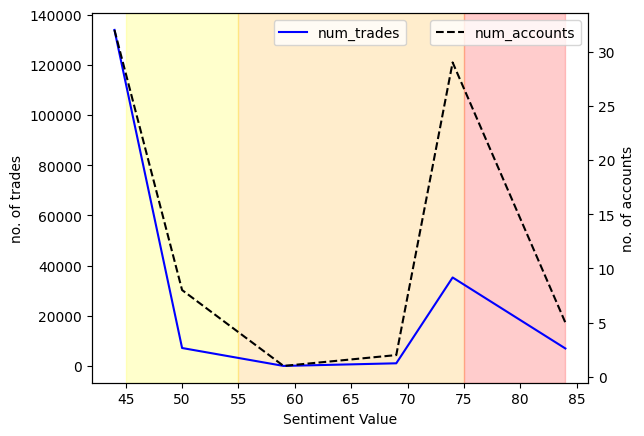

In [127]:
import matplotlib.pyplot as plt

analysis1 = daily_analysis.sort_values('value')

ax = analysis1.plot.line(x='value', y='num_trades', color='blue', label='num_trades')
ax.set_xlabel('Sentiment Value')
ax.set_ylabel('no. of trades')

ax2 = ax.twinx()
ax2.plot(analysis1['value'], analysis1['num_accounts'], linestyle='--', label='num_accounts', color='black')
ax2.set_ylabel('no. of accounts')


xmin = analysis1['value'].min()
xmax = analysis1['value'].max()

ax.axvspan(45, 55, alpha=0.2,color='yellow', label='neutral')
ax.axvspan(55, 75, alpha=0.2, color='orange', label='greed')
ax.axvspan(75, xmax, alpha=0.2, color='red', label='extreme greed')

plt.legend()
plt.show()

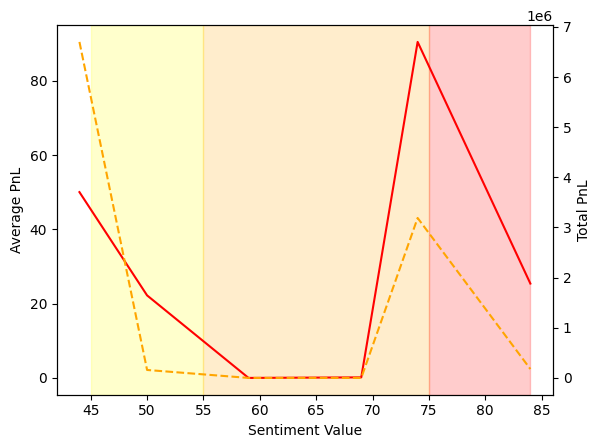

In [123]:
fig, ax1 = plt.subplots()

# first line (left y-axis)
ax1.plot(analysis1['value'], analysis1['avg_Pnl'], label='Average PnL', color='red')
ax1.set_xlabel('Sentiment Value')
ax1.set_ylabel('Average PnL')

# second line (right y-axis)
ax2 = ax1.twinx()
ax2.plot(analysis1['value'], analysis1['total_Pnl'], linestyle='--', label='Total PnL', color='orange')
ax2.set_ylabel('Total PnL')

# optional shaded sentiment regions
xmin = analysis1['value'].min()
xmax = analysis1['value'].max()

ax1.axvspan(45, 55, alpha=0.2,color='yellow', label='neutral')
ax1.axvspan(55, 75, alpha=0.2, color='orange', label='greed')
ax1.axvspan(75, xmax, alpha=0.2, color='red', label='extreme greed')

plt.show()

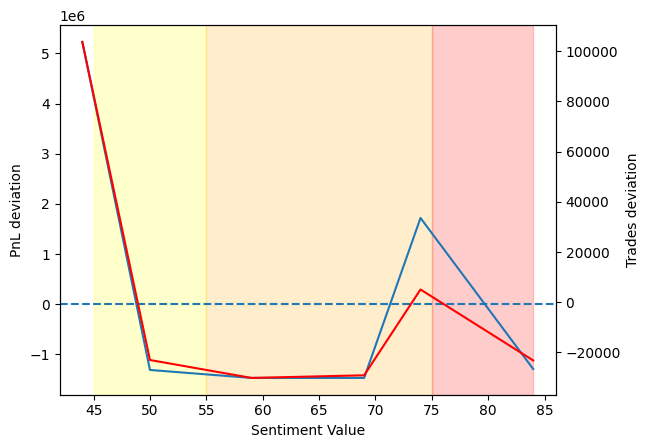

In [130]:
analysis = daily_analysis.copy()

analysis['pnl_dev'] = analysis['total_Pnl'] - analysis['total_Pnl'].mean()
analysis['trades_dev'] = analysis['num_trades'] - analysis['num_trades'].mean()

analysis = analysis.sort_values('value')

fig, ax1 = plt.subplots()

# PnL deviation
ax1.plot(analysis['value'], analysis['pnl_dev'], label='PnL deviation')
ax1.axhline(0, linestyle='--')  # baseline
ax1.set_ylabel("PnL deviation")

# second y-axis
ax2 = ax1.twinx()
ax2.plot(analysis['value'], analysis['trades_dev'], color='red', label='Trades deviation')
ax2.set_ylabel("Trades deviation")

ax1.set_xlabel("Sentiment Value")

xmin = analysis['value'].min()
xmax = analysis['value'].max()

ax1.axvspan(45, 55, alpha=0.2,color='yellow', label='neutral')
ax1.axvspan(55, 75, alpha=0.2, color='orange', label='greed')
ax1.axvspan(75, xmax, alpha=0.2, color='red', label='extreme greed')

plt.show()

In [137]:
analysis['sentiment_bucket'] = pd.qcut(analysis['value'],4)

analysis['pnl_dev %'] = (
    (analysis['total_Pnl'] - analysis['total_Pnl'].mean())
    / analysis['total_Pnl'].mean()
) * 100

analysis['trades_dev %'] = (
    (analysis['num_trades'] - analysis['num_trades'].mean())
    / analysis['num_trades'].mean()
) * 100 

analysis.groupby('sentiment_bucket', observed=False)[['pnl_dev', 'pnl_dev %','trades_dev', 'trades_dev %']].mean()


,pnl_dev,pnl_dev %,trades_dev,trades_dev %
sentiment_bucket,,,,
"(43.999, 52.25]",1.958340e+06,133.130351,40331.142857,133.658107
"(52.25, 64.0]",-1.470994e+06,-100.000000,-30171.857143,-99.990058
"(64.0, 72.75]",-1.470839e+06,-99.989429,-29129.857143,-96.536852
"(72.75, 84.0]",2.122191e+05,14.426919,-9073.357143,-30.069263
